##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 1

**Group name:** ain't no party like a data party😎




---

## 0. Iteration setup

**Import libraries**

In [68]:
%pip install pandas
%pip install matplotlib
%pip install scikit-learn
%pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


**Load dataset(s)**

In [69]:
df = pd.read_csv('data/energie en broeikasgassen 1990-2024.csv')
df2 = pd.read_csv('data/energie en broeikasgassen 1990-2024 verbruik.csv')

In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 834 entries, 0 to 833
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Jaar           834 non-null    int64  
 1   Balanspost     834 non-null    str    
 2   Energiedrager  834 non-null    str    
 3   Waarde in PJ   834 non-null    float64
dtypes: float64(1), int64(1), str(2)
memory usage: 26.2 KB


In [71]:
df.head()

,Jaar,Balanspost,Energiedrager,Waarde in PJ
0,1990,Winning,Totaal energiedragers,2542.1
1,1990,Winning,Aardoliegrondstoffen en producten,175.2
2,1990,Winning,Aardgas,2283.0
3,1990,Winning,Kernenergie,38.0
4,1990,Winning,Hernieuwbare energie,31.1


In [72]:
df.describe()

,Jaar,Waarde in PJ
count,834.000000,834.000000
mean,2007.786571,898.094245
std,10.061516,2184.531014
min,1990.000000,-362.200000
25%,1999.000000,1.100000
50%,2008.000000,38.100000
75%,2016.000000,216.500000
max,2024.000000,10473.600000


In [73]:
df.isna().sum()

Jaar             0
Balanspost       0
Energiedrager    0
Waarde in PJ     0
dtype: int64

In [74]:
df['Energiedrager'].unique()

<StringArray>
[            'Totaal energiedragers', 'Aardoliegrondstoffen en producten',
                           'Aardgas',                       'Kernenergie',
              'Hernieuwbare energie',                       'Waterkracht',
                       'Windenergie',                     'Zonne-energie',
                          'Biomassa',                            'Overig',
             'Kool en koolproducten',                     'Elektriciteit',
                  'Omgevingsenergie',                        'Aardwarmte']
Length: 14, dtype: str

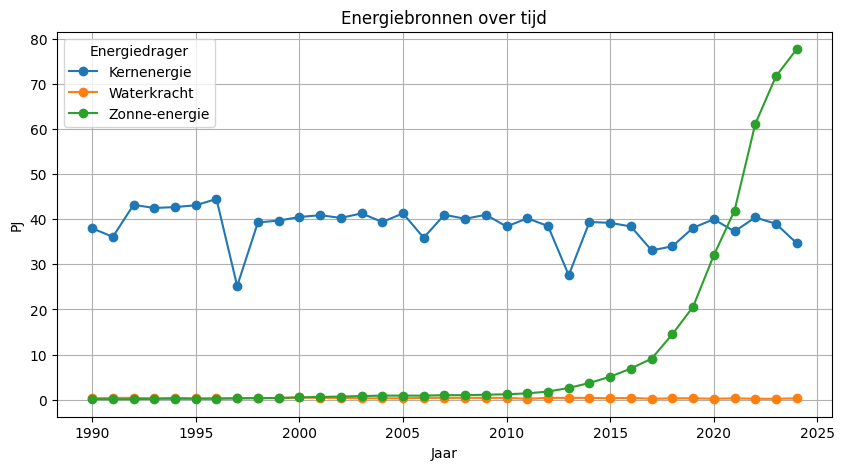

In [75]:
subset = df[df["Energiedrager"].isin([
    "Zonne-energie",
    "Kernenergie",
    "Waterkracht"
])]

pivot = subset.pivot_table(
    index="Jaar",
    columns="Energiedrager",
    values="Waarde in PJ",
    aggfunc="sum"
)

pivot.plot(figsize=(10,5), marker="o")

plt.title("Energiebronnen over tijd")
plt.xlabel("Jaar")
plt.ylabel("PJ")
plt.grid(True)

plt.show()

Tussen 1990 en 2010 zie je een redelijke stijging van aardgas en aardolie grondstoffen. Dit komt waarschijnlijk door de economische en industriele groei van Nederland. In 2019 was er natuurlijk Corona en zie je een duidelijke daling. Na 2020 komt er een duidelijke stijging omdat corona nu weg is en alles weer langzaam aan open gaat. Na deze stijging is er een blijvende daling door de oorlog in Oekraine en Israël. 

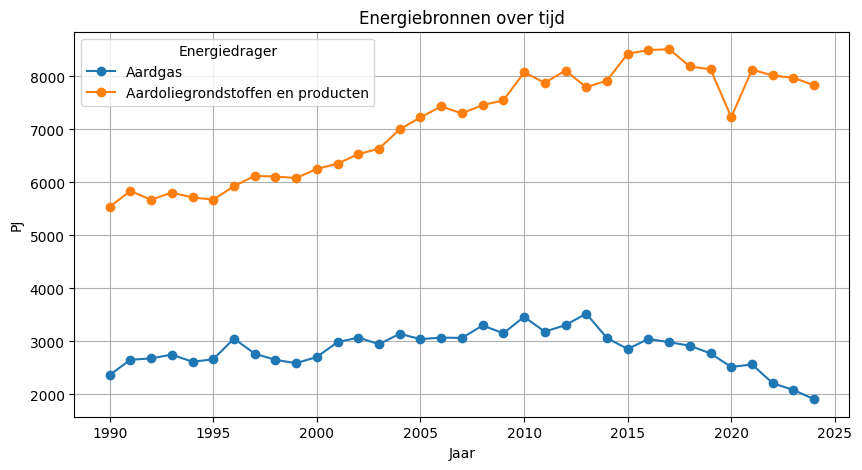

In [76]:
subset = df[df["Energiedrager"].isin([
    "Aardgas",
    "Aardoliegrondstoffen en producten",
    
])]

pivot = subset.pivot_table(
    index="Jaar",
    columns="Energiedrager",
    values="Waarde in PJ",
    aggfunc="sum"
)

pivot.plot(figsize=(10,5), marker="o")

plt.title("Energiebronnen over tijd")
plt.xlabel("Jaar")
plt.ylabel("PJ")
plt.grid(True)

plt.show()

Hier gaan we kijken naar de totale hoeveelheid energieverbruik per type. Hieruit komt dat aardolie en aardgas de grootste bronnen van energieverbruik zijn, voornamelijk olie. Aardgasverbruik wordt al lang vermindererd door de sluiting van de gaswinning in Groningen en de oorlog in Oekraine. De stijging van aardolieverbruik is waarschijnlijk te wijten aan de economische groei en de toegenomen vraag naar energie. De daling van het totale energieverbruik na 2020 kan worden toegeschreven aan de COVID-19-pandemie, die heeft geleid tot een vermindering van de economische activiteit en een verandering in het gedrag van consumenten.

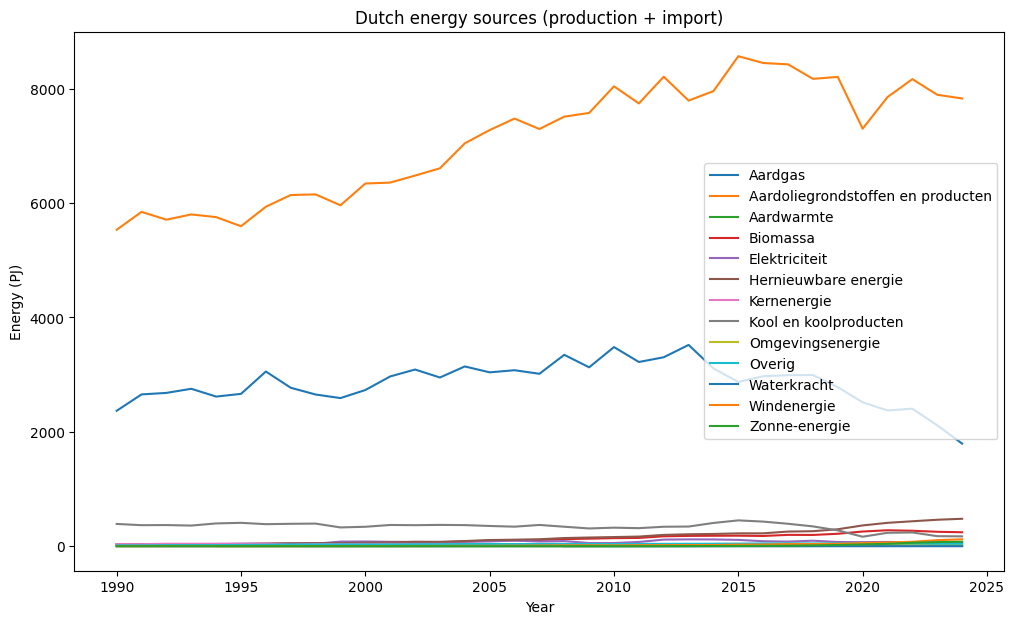

In [77]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(
    "data/energie en broeikasgassen 1990-2024.csv",
    sep=",",          # change to ";" if needed
    decimal="."
)

# Remove accidental spaces
df.columns = df.columns.str.strip()

# Keep only production + import
subset = df[
    df["Balanspost"].isin(["Winning", "Invoer"])
]

# Sum production and import together
grouped = (
    subset.groupby(["Jaar", "Energiedrager"])["Waarde in PJ"]
    .sum()
    .reset_index()
)

# Create pivot table for plotting
pivot = grouped.pivot(
    index="Jaar",
    columns="Energiedrager",
    values="Waarde in PJ"
)

# Optional: remove total category to avoid huge overlap
pivot = pivot.drop(columns=["Totaal energiedragers"], errors="ignore")

# Plot
plt.figure(figsize=(12,7))

for column in pivot.columns:
    plt.plot(
        pivot.index,
        pivot[column],
        label=column
    )

plt.xlabel("Year")
plt.ylabel("Energy (PJ)")
plt.title("Dutch energy sources (production + import)")
plt.legend()

plt.show()

Hier gaan we kijken waar olie aan wordt besteed. Hierin zien we dat wegverkeer en petrochemie het meeste olie verbruiken. Wegverkeer is natuurlijk logisch, omdat er veel auto's zijn die op olie rijden. Petrochemie is ook logisch, omdat er veel producten worden gemaakt van olie, zoals plastic en chemicaliën.

We moeten dus zoveel mogelijk wegverkeer en petrochemie verduurzamen, bijvoorbeeld door meer elektrische auto's te gebruiken en meer waterstof voor petrochemie.

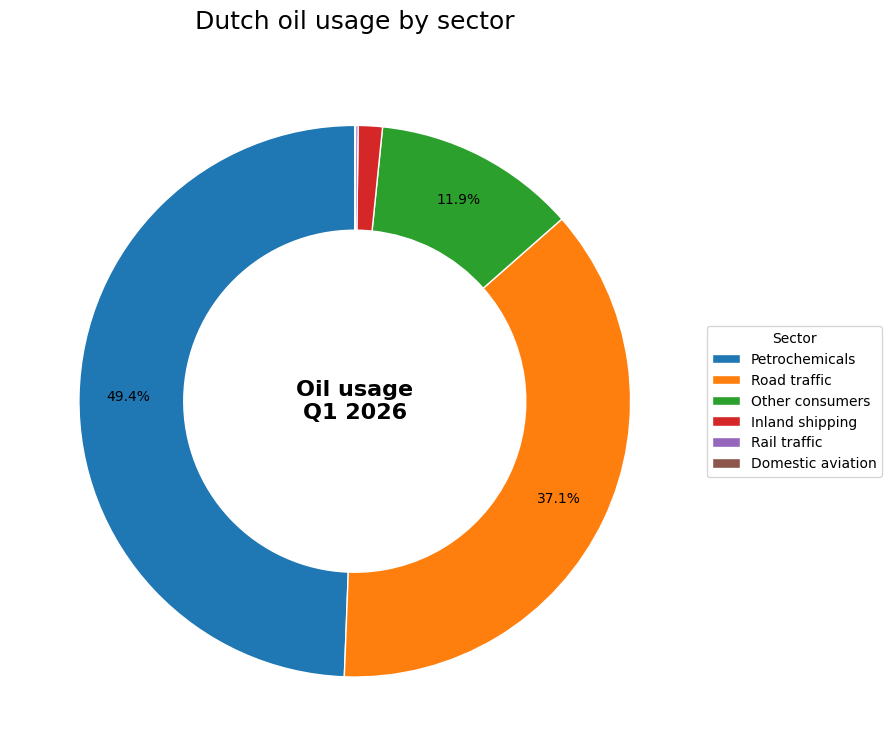

In [78]:
import matplotlib.pyplot as plt

# Oil usage by sector (Q1 2026)
labels = [
    "Petrochemicals",
    "Road traffic",
    "Other consumers",
    "Inland shipping",
    "Rail traffic",
    "Domestic aviation"
]

values = [
    2466,      # Niet-energetisch gebruik
    1851.55,   # Wegverkeer
    594.46,    # Overige afnemers
    70.72,     # Binnenlandse scheepvaart
    7.47,      # Railverkeer
    2.18       # Binnenlandse luchtvaart
]

# Create figure
fig, ax = plt.subplots(figsize=(9,9))

# Donut chart
wedges, texts, autotexts = ax.pie(
    values,
    labels=None,                 # cleaner look
    autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(width=0.38, edgecolor='white')
)

# Center circle text
ax.text(
    0, 0,
    "Oil usage\nQ1 2026",
    ha='center',
    va='center',
    fontsize=16,
    fontweight='bold'
)

# Legend on side
ax.legend(
    wedges,
    labels,
    title="Sector",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

# Clean title
ax.set_title(
    "Dutch oil usage by sector",
    fontsize=18,
    pad=20
)

plt.tight_layout()
plt.show()